In [1]:
# Cell 1: imports and load data
import os, joblib
import numpy as np
import pandas as pd

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ARTIFACTS_DIR = "artifacts"

# load TF-IDF train/test
X_train, y_train = joblib.load(os.path.join(ARTIFACTS_DIR, "train_tfidf.joblib"))
X_test,  y_test  = joblib.load(os.path.join(ARTIFACTS_DIR, "test_tfidf.joblib"))

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes :", X_test.shape, y_test.shape)
print("Classes:", y_train.unique())


Train shapes: (11712, 8055) (11712,)
Test shapes : (2928, 8055) (2928,)
Classes: ['neutral' 'negative' 'positive']


In [2]:
# Cell 2: helper to train / evaluate / save
def train_and_eval(model, name, X_train, y_train, X_test, y_test, save_dir=ARTIFACTS_DIR):
    print("="*60)
    print(f"Training model: {name}")
    model.fit(X_train, y_train)
    
    # predictions
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy ({name}): {acc:.4f}\n")
    print("Classification report:")
    print(classification_report(y_test, y_pred))
    
    # confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=sorted(y_train.unique()))
    print("Confusion matrix (rows=true, cols=pred):")
    print("Labels order:", sorted(y_train.unique()))
    print(cm)
    
    # save model
    path = os.path.join(save_dir, f"{name}_model.joblib")
    joblib.dump(model, path)
    print(f"\nSaved {name} model to: {path}\n")
    
    return acc, cm


In [3]:
# Cell 3: Multinomial Nave Bayes
nb = MultinomialNB()
acc_nb, cm_nb = train_and_eval(nb, "naive_bayes", X_train, y_train, X_test, y_test)

Training model: naive_bayes

Accuracy (naive_bayes): 0.7275

Classification report:
              precision    recall  f1-score   support

    negative       0.72      0.98      0.83      1835
     neutral       0.71      0.25      0.37       620
    positive       0.85      0.37      0.51       473

    accuracy                           0.73      2928
   macro avg       0.76      0.53      0.57      2928
weighted avg       0.74      0.73      0.68      2928

Confusion matrix (rows=true, cols=pred):
Labels order: ['negative', 'neutral', 'positive']
[[1801   26    8]
 [ 441  156   23]
 [ 261   39  173]]

Saved naive_bayes model to: artifacts\naive_bayes_model.joblib



In [4]:
# Cell 4: Logistic Regression
# C controls regularization strength; C=2.0 is a decent starting point
lr = LogisticRegression(
    C=2.0,
    max_iter=200,
    n_jobs=-1,
    class_weight=None,      # you can set 'balanced' if your classes are imbalanced
    solver="lbfgs",
    multi_class="multinomial"
)

acc_lr, cm_lr = train_and_eval(lr, "logistic_regression", X_train, y_train, X_test, y_test)


Training model: logistic_regression


C:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Accuracy (logistic_regression): 0.7756

Classification report:
              precision    recall  f1-score   support

    negative       0.80      0.93      0.86      1835
     neutral       0.62      0.47      0.54       620
    positive       0.80      0.56      0.66       473

    accuracy                           0.78      2928
   macro avg       0.74      0.66      0.69      2928
weighted avg       0.77      0.78      0.76      2928

Confusion matrix (rows=true, cols=pred):
Labels order: ['negative', 'neutral', 'positive']
[[1712   90   33]
 [ 295  292   33]
 [ 120   86  267]]

Saved logistic_regression model to: artifacts\logistic_regression_model.joblib



In [5]:
# Cell 5: Linear SVM (LinearSVC)
svm = LinearSVC(
    C=1.0
    # class_weight="balanced"  # uncomment if needed
)

acc_svm, cm_svm = train_and_eval(svm, "linear_svm", X_train, y_train, X_test, y_test)


Training model: linear_svm

Accuracy (linear_svm): 0.7654

Classification report:
              precision    recall  f1-score   support

    negative       0.83      0.89      0.85      1835
     neutral       0.57      0.53      0.55       620
    positive       0.74      0.61      0.67       473

    accuracy                           0.77      2928
   macro avg       0.71      0.67      0.69      2928
weighted avg       0.76      0.77      0.76      2928

Confusion matrix (rows=true, cols=pred):
Labels order: ['negative', 'neutral', 'positive']
[[1624  159   52]
 [ 244  329   47]
 [  99   86  288]]

Saved linear_svm model to: artifacts\linear_svm_model.joblib



In [6]:
# Cell 6: simple comparison table
results = pd.DataFrame({
    "model": ["Naive Bayes", "Logistic Regression", "Linear SVM"],
    "accuracy": [acc_nb, acc_lr, acc_svm]
}).sort_values("accuracy", ascending=False)

print("\nModel accuracy comparison:")
display(results)


Model accuracy comparison:


,model,accuracy
1,Logistic Regression,0.775615
2,Linear SVM,0.765369
0,Naive Bayes,0.727459


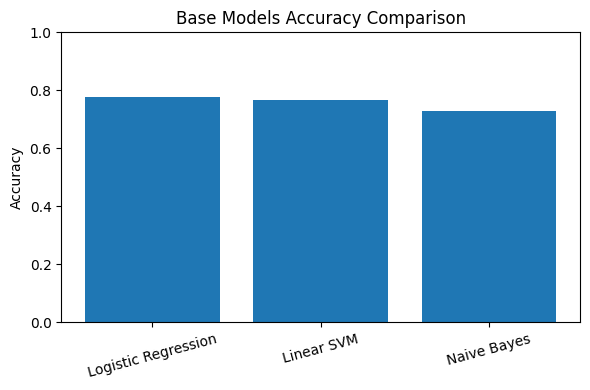

In [7]:
# Cell 7 (optional): bar plot of accuracies
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results["model"], results["accuracy"])
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Base Models Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()